# Tarea N.3 Integracion y diferensiacion numerica
**Arenas Limon Angel Daniel**

In [4]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Regla del Trapecio

El archivo velocidades.txt (adjunto), contiene dos columnas de numeros, la primera  ́
representa el tiempo $t$ en segundos y la segunda la $x-velocidad$ en metros por segundo
de una partıcula, medida una vez por segundo desde el tiempo $t = 0$ hasta $t = 100$.

**(a)** Lee los datos y, usando la regla del trapecio, calcula a partir de ellos la distancia aproximada recorrida por la part ́ıcula en la direccion x como una funcion del ́ tiempo.

In [65]:
##Esta es la interal del trapecio que hicimos en clase pero no lee listas
def Int1(f,a,b,N):
    h = (b-a)/N
    A=0
    for i in range(0,N):
        A += (f(a+(i*h))) * h
    return(A)

In [2]:
velocidad=[]
tiempo=[]
with open("velocidades.txt","r") as V:
    for i in V:
        datos = i.strip().split()
        if len(datos) == 2:  
            tiempo.append(int(datos[0]))  
            velocidad.append(float(datos[1]))  

In [112]:
#Modificacion de la funcion de arriba pero para listas

def trapecio_L(lista_1,lista_2):#aqui solo nos interesa meterle las listas
                                #, pues estas ya tienen un numero fijo de valores que no tenemos que definir
    N = len(lista_1) 
    h = (lista_1[-1] - lista_1[0])/N #Este seria mi eje 'x'
    I=0
    for i in range(0,N):
        I += h*(lista_2[i] + i*h)
    return(I)

print("El valor de la integral",trapecio_L(tiempo,velocidad))

El valor de la integral 4958.799582178219


**b)** Extiende tu programa para hacer una grafica que muestre, en el mismo grafico,  ́
tanto la curva de velocidad original como la distancia recorrida como una funcion ́

In [33]:
def trapecio_L1(lista_1, lista_2):
    N = len(lista_1) - 1
    I=0
    distancia=[]#esta es mi lista que guarda valores
    for i in range(N):
        h = (lista_1[i+1] - lista_1[i])/N
        I = (h/2) * (lista_2[i]+ lista_2[i+1])
        I += h*(lista_2[i] + i*h)
        distancia.append(I)#aqui vamos guardando las iteraciones de la integral
    return distancia#Esta es la funcion modificada

distancia = trapecio_L1(tiempo, velocidad)
#aqui ya vi que si guarda los valores en forma de lista, pero para no crear un archivo .txt la voy a guardar como una variable para graficar

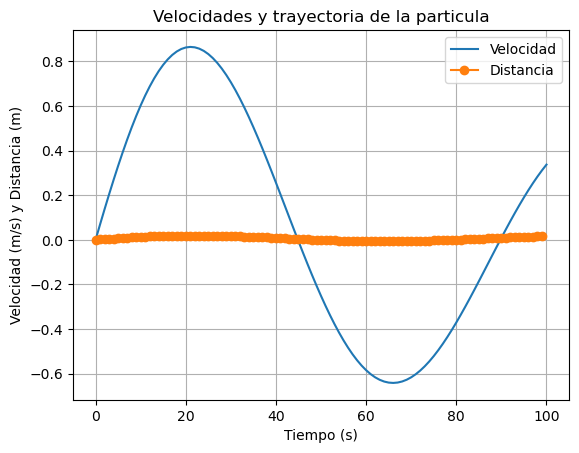

In [39]:
plt.plot(tiempo,velocidad,label="Velocidad")
plt.plot(tiempo[:-1], distancia, marker='o', label="Distancia")
plt.title("Velocidades y trayectoria de la particula")
plt.grid()
plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad (m/s) y Distancia (m)")
plt.legend()
plt.show()

## 2. Integracion numerica.

**a)** Escribe un programa para calcular un valor aproximado para la integral

\begin{align}
    \int\limits^2_0 \left(x^4 - 2x  + 1\right)dx
\end{align}

utilizando tanto la regla del trapecio, como la regla de Simpson con 10 divisiones.

In [85]:
x=np.linspace(0,2,100)
def fx1(x):
    return(x**4 -2*x +1)
print(fx1)

<function fx1 at 0x7d0ac7b9a520>


In [93]:
def simpson(f,a,b,N):
    h = (b - a) / N
    x = [a + i * h for i in range(N + 1)]
    suma = f(a) + f(b) #aqui lo renombre 
    for i in range(1, N):  # i = 1, 2, ..., N-1
        if i % 2 == 0:  # par
            suma += 2 * f(x[i]) #lo renombre suma por que no compilaba
        else:  # impar
            suma += 4 * f(x[i])
    return (h / 3) * suma

In [99]:
print("El valor de la integral por trapecio es: ",Int1(fx1,0,2,10))
print("El valor de la integral por Simpson es: ",simpson(fx1,0,2,10))

El valor de la integral por trapecio es:  3.306560000000001
El valor de la integral por Simpson es:  4.400426666666667


**b)** Ejecuta el programa y compara tu resultado con el valor correcto conocido de $4,4$.
¿Cual es el error en tu calculo?  ́

**Creo que es lo mismo de arriba, si no una disculpa me confundi**

**c)** Modifica el programa para utilizar 100 divisiones y luego 1000. ¿Como mejora  ́
el resultado?. ¿Como se comparan los resultados entre ambas reglas al usar la  ́
misma cantidad de divisiones?

In [101]:
print("El valor de la integral por trapecio es: ",Int1(fx1,0,2,100))
print("El valor de la integral por Simpson es: ",simpson(fx1,0,2,100))

El valor de la integral por trapecio es:  4.281066655999999
El valor de la integral por Simpson es:  4.400000042666667


In [103]:
print("El valor de la integral por trapecio es: ",Int1(fx1,0,2,1000))
print("El valor de la integral por Simpson es: ",simpson(fx1,0,2,1000))

El valor de la integral por trapecio es:  4.3880106666656
El valor de la integral por Simpson es:  4.400000000004266


**Simposon aproxima de mejor manera al acercar la curva con pilinomios**

## 3.El lımite de difraccion de un telescopio

Nuestra capacidad para resolver detalles en observaciones astronomicas esta limitada por la difraccion de la luz en nuestros telescopios. La luz de las estrellas puede considerarse efectivamente como si proviniera de una fuente puntual en el infinito. Cuando dicha luz, con una longitud de onda $\lambda$, pasa a traves de la apertura circular de un telescopio (que supondremos que tiene un radio unitario) y es enfocada por el telescopio en el plano focal, no produce un solo punto, sino un patron de difraccion circular que consta de un punto central rodeado por una serie de anillos concentricos. La intensidad de la luz en este patron de difraccion esta dada por: 

\begin{align}  I(r)= \left( \frac{J_1(kr)}{kr} \right)^2 \end{align}

donde $r$ es la distancia en el plano focal desde el centro del patron de difraccion,  $k =
2\pi/\lambda$ y $J_1(x)$ es una funcion de Bessel. Las funciones de Bessel  $Jm(x)$ estan dadas por:

́\begin{align} J_m(x) = \frac{1}{\pi} \int \limits^{\pi}_{0} Cos(m \theta - x Sen(\theta)) d \theta \end{align}

donde $m$ es un entero no negativo y $x ≥ 0$.

**a)** Escribe una funcion $J(m,x)$ que calcule el valor de $J_m(x)$ usando la regla de Simpson con $N = 1000 puntos$. Utiliza dicha funcion en un programa para graficar, en un solo grafico, las funciones de Bessel  $J_0, J_1$ y $J_2$ como una funcion de  $x$ (de $x = 0$ a $x = 20$).

In [114]:
def J(m,x):
    def fun(theta): #No sabia que podia definir una funcion dentro de una funcion, pero asi hacemos que se integre respecto a theta
        f= np.cos((m*theta) - (x*np.sin(theta)))
        return f
    j_m = (1/np.pi) * simpson(0, np.pi, fun,1000)
    return j_m

In [71]:
x = np.linspace(0, 20, 200)
j_0 = [J(0, x) for x in x] #primero habia intentando meter el for en J(m,x) pero solo me daba un valor,
                            #espero que estos si sean lo que querian 
j_1 = [J(1, x) for x in x]
j_2 = [J(2, x) for x in x]

print(j_0,j_1,j_2) #0o0

[1.0000000000000002, 0.9974764049394963, 0.9899247226737871, 0.9774021012850238, 0.9600032534448567, 0.9378596601694553, 0.9111384659362908, 0.8800410749147337, 0.8448014606965393, 0.8056842044334517, 0.7629822786754732, 0.7170145964323683, 0.6681233470332252, 0.6166711422155071, 0.5630379975193475, 0.5076181754802479, 0.4508169182909909, 0.3930470985312537, 0.3347258172327168, 0.27627097895289915, 0.21809787366904293, 0.16061579517321412, 0.10422472525315858, 0.04931211228420239, -0.0037502280578505863, -0.054609063415461664, -0.10293252155127465, -0.14841266980664966, -0.1907678755199671, -0.22974492772829946, -0.2651209026682904, -0.296704757935828, -0.3243386426375512, -0.3478989134475172, -0.36729684914566, -0.3824790589364362, -0.3934275826012761, -0.40015968330182294, -0.4027273365972752, -0.40121642194316703, -0.39574562557626747, -0.3864650662368342, -0.37355465761219325, -0.35722222368276524, -0.33770138529236476, -0.31524923823003553, -0.29014384488310946, -0.262681563085342

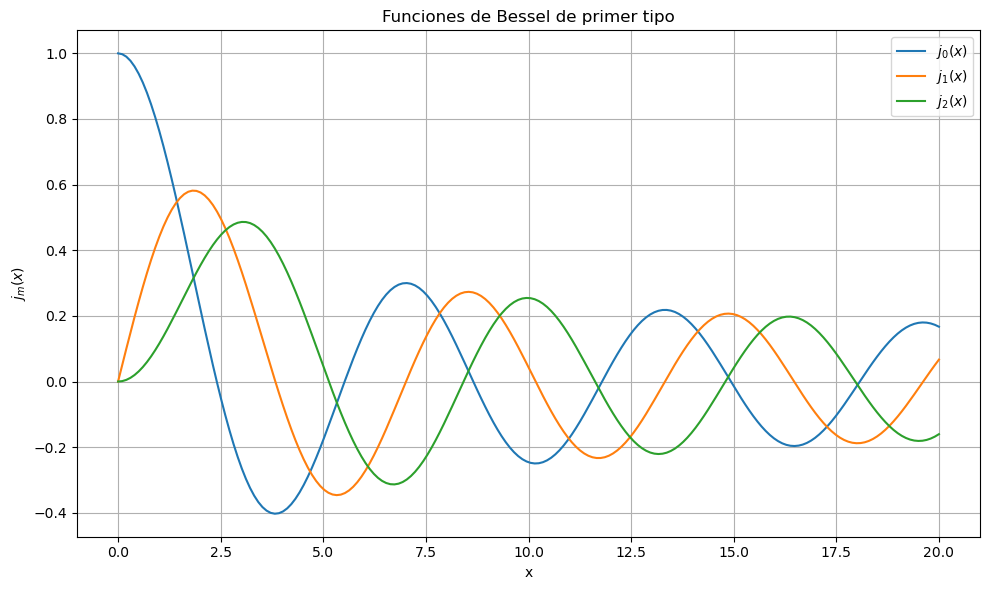

In [73]:
plt.figure(figsize=(10, 6))
plt.plot(x, j_0, label=r"$j_0(x)$")
plt.plot(x, j_1, label=r"$j_1(x)$")
plt.plot(x, j_2, label=r"$j_2(x)$")
plt.title("Funciones de Bessel de primer tipo")
plt.xlabel("x")
plt.ylabel(r"$j_m(x)$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

**b)** Compara tus resultados con los proporcionados con la biblioteca de scipy que
implementa la regla de Simpson.

In [75]:
from scipy.special import jn
print(jn(0, x),j_0)
print(jn(1, x),j_1)
print(jn(2, x),j_2)

[ 1.          0.9974764   0.98992472  0.9774021   0.96000325  0.93785966
  0.91113847  0.88004107  0.84480146  0.8056842   0.76298228  0.7170146
  0.66812335  0.61667114  0.563038    0.50761818  0.45081692  0.3930471
  0.33472582  0.27627098  0.21809787  0.1606158   0.10422473  0.04931211
 -0.00375023 -0.05460906 -0.10293252 -0.14841267 -0.19076788 -0.22974493
 -0.2651209  -0.29670476 -0.32433864 -0.34789891 -0.36729685 -0.38247906
 -0.39342758 -0.40015968 -0.40272734 -0.40121642 -0.39574563 -0.38646507
 -0.37355466 -0.35722222 -0.33770139 -0.31524924 -0.29014384 -0.26268156
 -0.23317424 -0.20194628 -0.16933165 -0.13567083 -0.10130769 -0.0665864
 -0.0318484   0.00257064  0.03634379  0.06915559  0.10070484  0.13070708
  0.15889698  0.1850305   0.20888683  0.23027013  0.24901097  0.2649676
  0.27802684  0.28810482  0.29514735  0.29913006  0.30005823  0.29796639
  0.29291764  0.28500267  0.27433859  0.2610675   0.24535485  0.22738756
  0.20737204  0.18553194  0.16210589  0.13734498  0.111

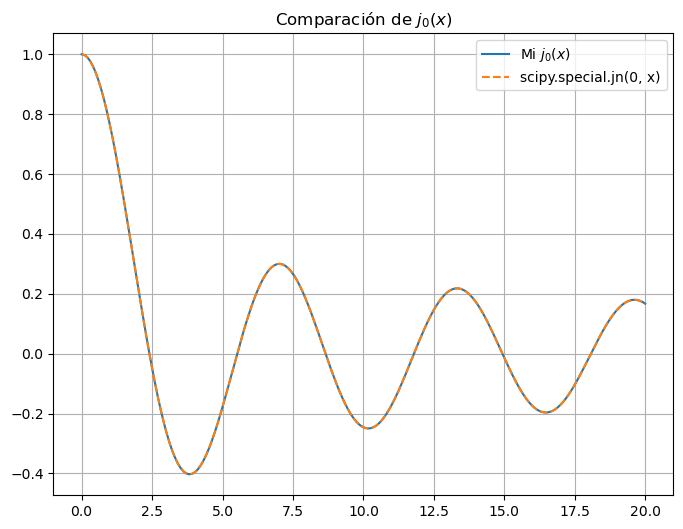

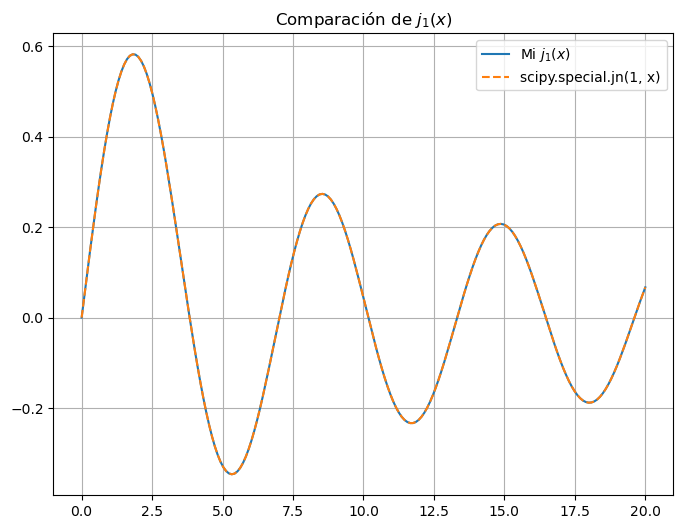

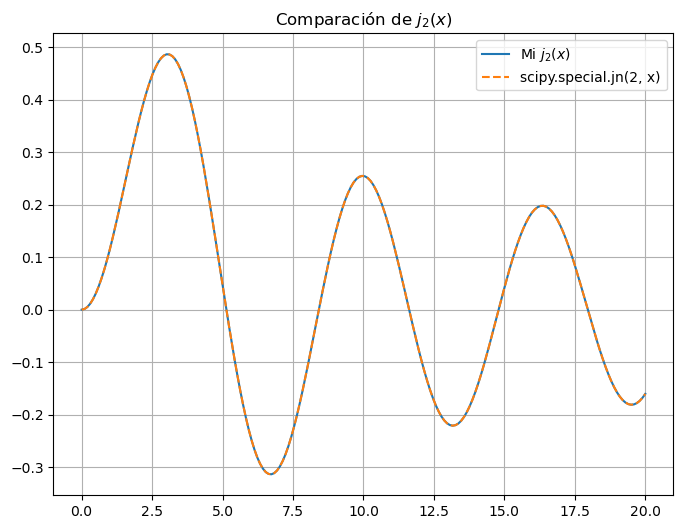

In [77]:
j_0_s = jn(0, x)
j_1_s = jn(1, x)
j_2_s = jn(2, x)

plt.figure(figsize=(8, 6))
plt.plot(x, j_0, label="Mi $j_0(x)$")
plt.plot(x, j_0_s, "--", label="scipy.special.jn(0, x)")
plt.title("Comparación de $j_0(x)$")
plt.legend()
plt.grid()
plt.show()
plt.figure(figsize=(8, 6))
plt.plot(x, j_1, label="Mi $j_1(x)$")
plt.plot(x, j_1_s, "--", label="scipy.special.jn(1, x)")
plt.title("Comparación de $j_1(x)$")
plt.legend()
plt.grid()
plt.show()
plt.figure(figsize=(8, 6))
plt.plot(x, j_2, label="Mi $j_2(x)$")
plt.plot(x, j_2_s, "--", label="scipy.special.jn(2, x)")
plt.title("Comparación de $j_2(x)$")
plt.legend()
plt.grid()
plt.show()

**c)** Escribe un segundo programa que haga una grafica de densidad (density plot) de la intensidad del patron de difraccion circular de una fuente de luz puntual con $\lambda = 500 nm$, en una region cuadrada del plano focal, usando la formula dada  anteriormente. Su imagen debe cubrir valores de r desde cero hasta aproximadamente 1 $\mu m$. ̧

In [79]:
from scipy.special import j1
def I(r):
    k = 2*np.pi/(500*10**(-9))
    kr = k*r
    with np.errstate(divide='ignore', invalid='ignore'): #aun que defini el valor en 0=1/4 no queria jalar
                                                            #fue magia, o insipiracion divina 
        I = (j1(kr)/(k*r))**2
        I[kr == 0] = 0.25
    return I

x = np.linspace(-1*10**(-6), 1*10**(-6), 400) #esto pues es para crear mis ejes en "x" y "y"
y = np.linspace(-1*10**(-6), 1*10**(-6), 400)
x,y = np.meshgrid(x, y) #por lo que lei de density en matplotlib me daba puros hitoriagramas. y no entendia muy bien como usarla, pero vi que solo recibe un valor que vealua en una malla o matriz
                        # La funcion x,y me crea una maya para la funcion de plt.imshow, que ocupoa una matriz 2D y esto representa esa matriz
r = np.sqrt(x**2 + y**2) 
I_r = I(r)

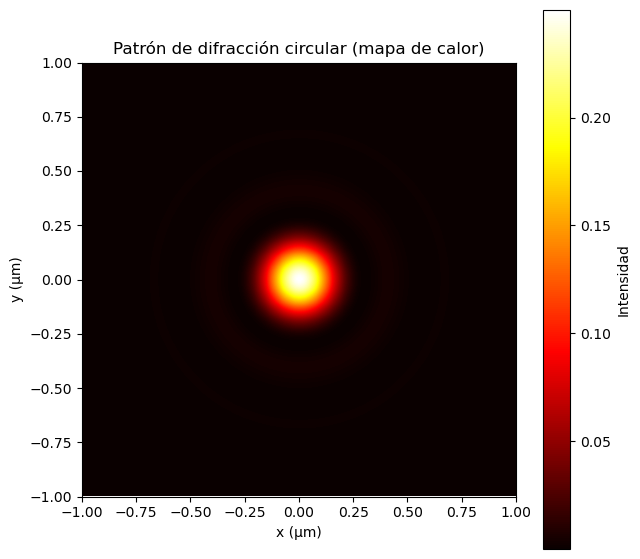

In [81]:
plt.figure(figsize=(7, 7))
plt.imshow(I_r, extent=[-1, 1, -1, 1],cmap='hot',origin='lower')
plt.colorbar(label="Intensidad")
plt.title("Patrón de difracción circular (mapa de calor)")
plt.xlabel("x (μm)")
plt.ylabel("y (μm)")
plt.show()

## 4. Capacidad calorıfica de un solido

La teorıa de solidos de Debye dice que la capacidad calorıfica de un solido a una temperatura T esta dada por: 

\begin{align} C_v = 9V \rho K_B \left( \frac{T}{\theta_{D}} \right)^3 \int \limits^{\theta_D/T}_{0} \frac{x^4 e^x}{(e^x -1)^2} dx \end{align}

donde $V$ es el volumen del solido,  $\rho$ es la densidad numerica de los atomos,  $K_B$ es la
constante de Boltzmann y $\theta_D$ es la llamada temperatura de Debye, una propiedad de solidos que depende de su densidad y la velocidad del sonido.

**a)** Escribe una funcion $C_v(T)$ que calcule la $C_V$ para un valor dado de temperatura,
de una muestra que consta de 1000 centımetros cubicos de aluminio solido, con densidad numerica de $\rho = 6.022 × 10^{28} m^{−3}$ y una temperatura de Debye de $\theta_D = 428 K$. Utiliza la cuadratura gaussiana para evaluar la integral, con $N = 50$ puntos muestra.

In [25]:
import scipy as sp


def Gauss(f,a,b,N):
    xk,wk= sp.special.roots_legendre(N)
    xkp= 0.5*(b-a)*xk+0.5*(b+a)
    wkp= 0.5*(b-a)*wk

    s=0
    for i in range(N):
        s= s +wkp[i]*f(xkp[i])
    return s

def f_1(x):
    return((x**4 * np.exp(x))/(np.exp(x)  -1)**2) #esta es la funcion a integrar
     


#Funcion de capacidad Calorifica
def C_v(T):
    Th_D = 428/T
    C = 9*(1000e-6)*(6.022e28)*(1.38064e-23)*((T/428)**3)
    Cv = C* Gauss(f_1,0,Th_D,50)
    
    return Cv

T_rango = np.linspace(5, 500, 100)#solo espero que si sean 5[K] y no 5000, una disculpa 

for i in T_rango:
    print("La capacidad calorıfica a",i," es de:",C_v(i),"[J/K]")

La capacidad calorıfica a 5.0  es de: 0.3098921972260235 [J/K]
La capacidad calorıfica a 10.0  es de: 2.4791375778081135 [J/K]
La capacidad calorıfica a 15.0  es de: 8.367089224986772 [J/K]
La capacidad calorıfica a 20.0  es de: 19.833001677046116 [J/K]
La capacidad calorıfica a 25.0  es de: 38.73050547717925 [J/K]
La capacidad calorıfica a 30.0  es de: 66.84505072496978 [J/K]
La capacidad calorıfica a 35.0  es de: 105.6571049718911 [J/K]
La capacidad calorıfica a 40.0  es de: 155.95701493672595 [J/K]
La capacidad calorıfica a 45.0  es de: 217.5656926508748 [J/K]
La capacidad calorıfica a 50.0  es de: 289.34549027534075 [J/K]
La capacidad calorıfica a 55.0  es de: 369.4567569013927 [J/K]
La capacidad calorıfica a 60.0  es de: 455.7059205933558 [J/K]
La capacidad calorıfica a 65.0  es de: 545.8580625883002 [J/K]
La capacidad calorıfica a 70.0  es de: 637.8563356755704 [J/K]
La capacidad calorıfica a 75.0  es de: 729.943572468462 [J/K]
La capacidad calorıfica a 80.0  es de: 820.706653727

**b)** Usa tu funcion para hacer una grafica de la capacidad calorıfica en funcion de la  temperatura desde $T = 5 K$ hasta $T = 500 K$.

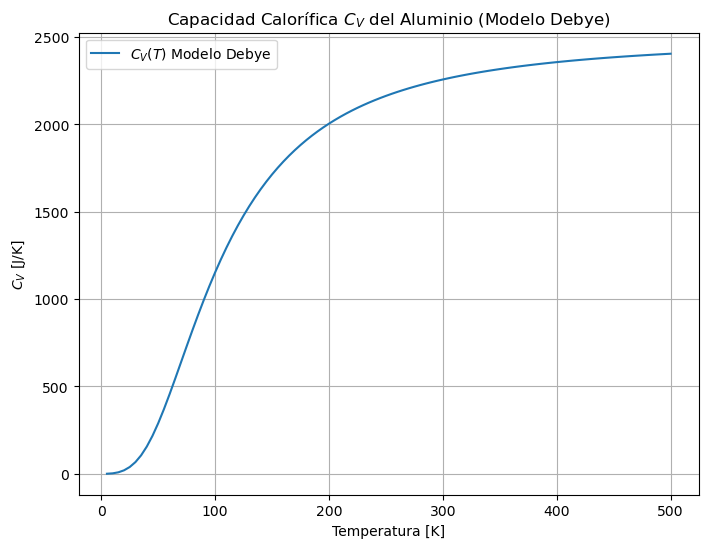

In [29]:
T_mesh, _ = np.meshgrid(T_rango, [0])  # Meshgrid de 1D porque me dio curiosidad 

# Evaluar C_v para cada T
Cv_valores = np.array([C_v(T) for T in T_mesh[0]])

# Graficar
plt.figure(figsize=(8,6))
plt.plot(T_mesh[0], Cv_valores, label=r'$C_V(T)$ Modelo Debye')
plt.xlabel('Temperatura [K]')
plt.ylabel(r'$C_V$ [J/K]')
plt.title(r'Capacidad Calorífica $C_V$ del Aluminio (Modelo Debye)')
plt.grid(True)
plt.legend()
plt.show()

## 5 Atraccion gravitacional de una lamina uniforme

Una lamina de metal cuadrada uniforme flota inmovil en el espacio:  ́

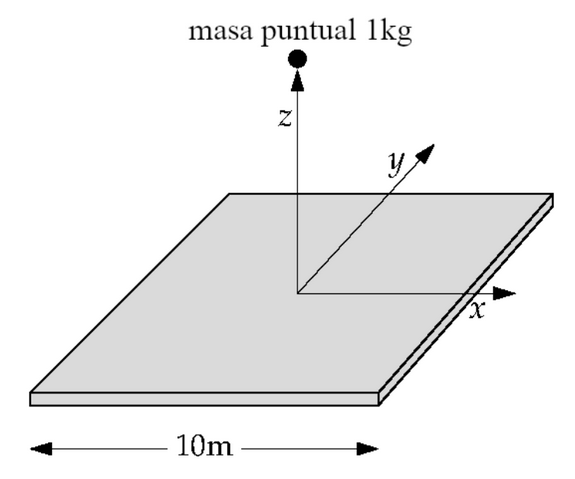

**a)** Considera la fuerza gravitacional debida a la placa que siente una masa puntual de 1 kg a una distancia z del centro del cuadrado, en direccion perpendicular a la lamina, como se muestra en la figura. Demuestra que la componente de la fuerza a lo largo del eje z es.

\begin{align}
    F_z = G \sigma z \iint \limits^{L/2}_{-L/2} \frac{dx dy}{(x^2 + y^2 + z^2)^{3/2}}
\end{align}

donde $G = 6.674 × 10^{−11} m^{3} kg^{−1} s^{−2}$ es la constante gravitacional de Newton y $\sigma$ es la masa por unidad de area de la hoja. 

**Dem**

La fuerza diferencial que ejerce un elemento $dA$ de la lámina sobre la masa puntual es:

\begin{align}
    d\mathbf{F} = -G \frac{dm\,m}{r^2} \hat{\mathbf{r}}
\end{align}

Donde $dm = \sigma\,dx\,dy$ y $r = \sqrt{x^2 + y^2 + z^2}$


\begin{align}
    \hat{\mathbf{r}} = \frac{\mathbf{r}}{r} = \frac{\langle x, y, z \rangle}{r}
\end{align}

Entonces la contribución diferencial es:

\begin{align}
    d\mathbf{F} = -G \frac{m\,dm}{r^2} \frac{\mathbf{r}}{r} = -G \frac{m\,dm}{r^3} \mathbf{r}
\end{align}

La componente en $z$ es:

\begin{align}
    dF_z = -G \frac{m\,dm}{r^3} z
\end{align}

El signo negativo indica que la fuerza es hacia la lámina.


\begin{align}
    dm = \sigma\,dx\,dy
    \quad \text{Y como} \quad m = 1\,kg, 
    \quad dF_z = -G \sigma z\, \frac{dx\,dy}{(x^2 + y^2 + z^2)^{3/2}}
\end{align}


La fuerza total es la suma sobre toda el área:

\begin{align}
    F_z = -G \sigma z \iint_{-L/2}^{L/2} \frac{dx\,dy}{(x^2 + y^2 + z^2)^{3/2}}.
\end{align}

El signo negativo indica dirección hacia la lámina. Por convención, se expresa como magnitud:

\begin{align}
    F_z = G \sigma z \iint_{-L/2}^{L/2} \frac{dx\,dy}{(x^2 + y^2 + z^2)^{3/2}}.
\end{align}

Usando simetría, las componentes en $x$ y $y$ se cancelan por simetría, solo queda la componente $z$. Esta forma es válida para cualquier $z > 0$. Para $L \to \infty$ (lámina infinita), se obtiene la fuerza gravitacional de un plano infinito:

\begin{align}
    \lim_{L \to \infty} F_z = 2\pi G \sigma.
    \quad (\text{Constante con } z)
\end{align}


**b)** Escribe un programa para calcular y graficar la fuerza en funcion de  $z$ de $z = 0$ hasta $z = 10 m$. Para la integral doble utiliza la cuadratura Gaussiana (doble)

\begin{align}
    I \approx \sum^N_{I=0}  \sum^N_{j=0} \omega_i \omega_j f(x_i,x_j)
\end{align}

con 100 puntos de muestra a lo largo de cada eje.

In [65]:
from scipy.special import roots_legendre

def I_D(z, L, N): 
    # z es la distancia perpendicular desde el centro de la lámina hasta la masa puntual de prueba
    # L es la longitud del lado de la lámina cuadrada que en la imagen son 10[m]
    xk, wk = roots_legendre(N)
    
    # Cambio de variable a [-L/2,L/2]
    xk = 0.5 * L * xk
    wk = 0.5 * L * wk

    suma = 0.0
    for i in range(N):
        for j in range(N):
            x = xk[i]
            y = xk[j]
            w = wk[i] * wk[j]
            denominador = (x**2 + y**2 + z**2)**(3/2)
            suma += w / denominador
    return suma

def F_z(z, L, N):
    G = 6.67430e-11  # m^3 kg^-1 s^-2
    sigma = 1  # kg/m^2
    Int = I_D(z, L, N)
    return G * sigma * z * Int

print(F_z(10, 10,100), "[N]")

5.3756926829236033e-11 [N]


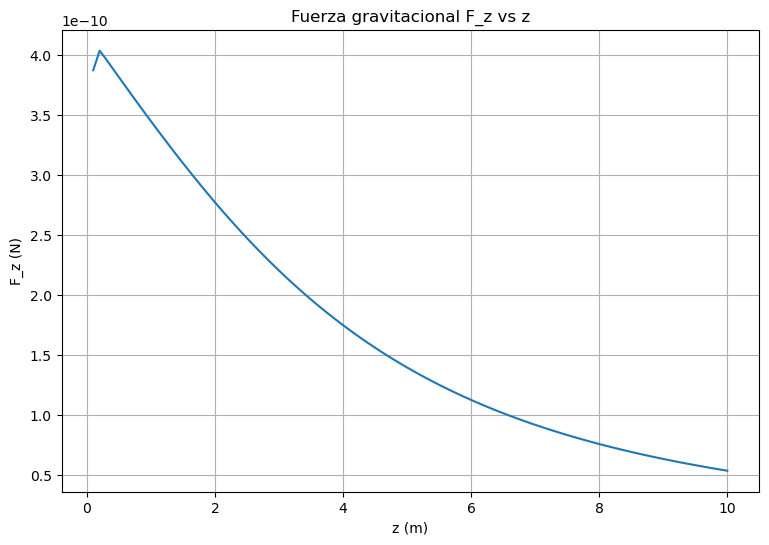

In [93]:
Z = np.linspace(0.1, 10, 100)

Fz_valores = []

for z in Z:
    Fs = F_z(z, 10, 100)
    Fz_valores.append(Fs)
        

plt.figure(figsize=(9, 6))
plt.plot(Z, Fz_valores)
plt.xlabel("z (m)")
plt.ylabel("F_z (N)")
plt.title("Fuerza gravitacional F_z vs z")
plt.grid(True)
plt.show()

**c)** Deberıas ver una curva suave, excepto en valores muy pequenos de  z, donde la
fuerza deberıa caer repentinamente a cero. Esta ca ́ıda no es un efecto real, sino
un artefacto de la forma en que hemos realizado el calculo. Explica brevemente  ́
de donde viene este artefacto y sugiere una estrategia para eliminarlo, o al menos  ́
disminuir su tamano.  